In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
titanic = titanic.drop(['deck', 'embark_town', 'alive', 'class', 'who', 'adult_male'], axis=1)

titanic = titanic.dropna()

titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
titanic['alone'] = titanic['alone'].map({False: 0, True: 1})

X = titanic.drop('survived', axis=1)
y = titanic['survived']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [5]:
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

In [6]:
y_pred = model.predict(X_test)


Accuracy: 0.6853146853146853

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.82      0.75        80
           1       0.70      0.51      0.59        63

    accuracy                           0.69       143
   macro avg       0.69      0.67      0.67       143
weighted avg       0.69      0.69      0.68       143



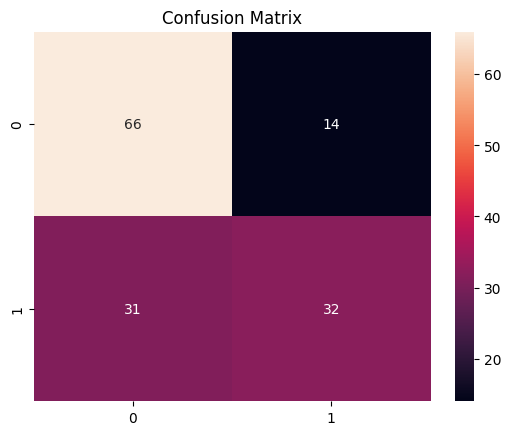

In [7]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()


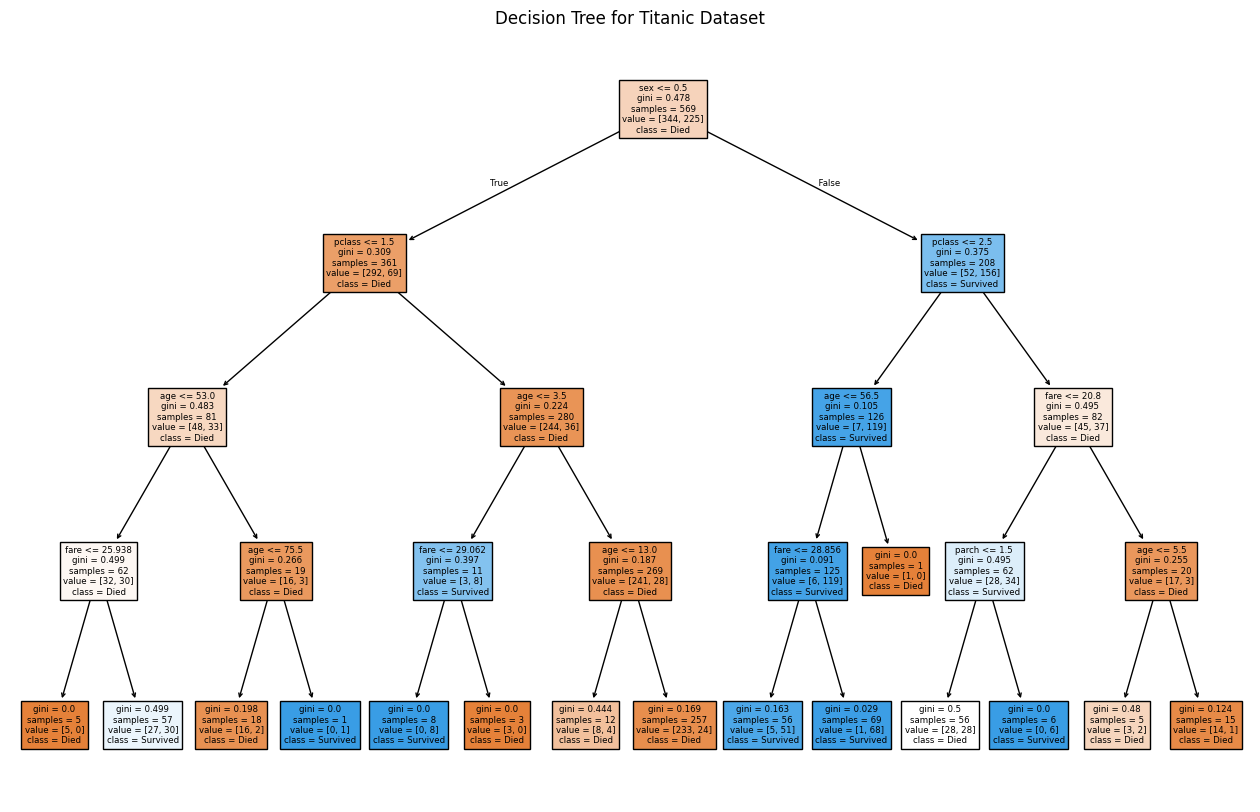

In [8]:
plt.figure(figsize=(16, 10))
plot_tree(model, feature_names=X.columns, class_names=["Died", "Survived"], filled=True)
plt.title("Decision Tree for Titanic Dataset")
plt.show()
